# Grid extension

`extend_grid(x, new_grid_size)` changes a `KANLinear`/`KAN`'s `grid_size` (finer or coarser) while refitting the spline coefficients via least squares, so the function currently represented is preserved. This is the "grid extension" technique from the original KAN paper: start on a coarse, cheap grid and progressively refine it during training.

We fit the paper's classic 2-variable benchmark:

$$f(x, y) = \exp(\sin(\pi x) + y^2)$$

with `KAN([2, 1, 1])`. A single hidden node is enough, since $f$ decomposes exactly as $\phi_3(\phi_1(x) + \phi_2(y))$ with $\phi_1 = \sin(\pi\cdot)$, $\phi_2 = (\cdot)^2$, $\phi_3 = \exp(\cdot)$ — precisely the shape a width-`[2,1,1]` KAN can represent. We extend the grid through $3 \to 5 \to 10 \to 20$, watching the loss drop at each step.

In [1]:
import torch
import matplotlib.pyplot as plt

from efficient_kan import KAN

In [2]:
def target_fn(x):
    return torch.exp(torch.sin(torch.pi * x[:, 0]) + x[:, 1] ** 2)


def make_dataset(n):
    x = torch.rand(n, 2) * 2 - 1  # uniform on [-1, 1]^2
    y = target_fn(x).unsqueeze(-1)
    return x, y


torch.manual_seed(1)
grid_sizes = [3, 5, 10, 20]
model = KAN([2, 1, 1], grid_size=grid_sizes[0], spline_order=3)
x_train, y_train = make_dataset(1000)
x_test, y_test = make_dataset(1000)

## Training helper

A small LBFGS loop reporting train/test MSE at every step, so we can watch the loss across grid extensions. `lr=0.5` avoids a transient overshoot right after a large grid extension.

In [3]:
def train_steps(model, n_steps, lr=0.5):
    optimizer = torch.optim.LBFGS(
        model.parameters(), lr=lr, history_size=10, line_search_fn="strong_wolfe"
    )
    train_losses, test_losses = [], []
    for _ in range(n_steps):
        def closure():
            optimizer.zero_grad()
            pred = model(x_train)
            loss = torch.nn.functional.mse_loss(pred, y_train)
            loss.backward()
            return loss

        loss = optimizer.step(closure)
        with torch.no_grad():
            test_loss = torch.nn.functional.mse_loss(model(x_test), y_test)
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
    return train_losses, test_losses

## Progressive grid extension

Train on `grid_size=3`, then repeatedly call `model.extend_grid(x_train, new_grid_size=...)` to refine the grid and keep training.

In [4]:
steps_per_stage = 25

all_train_losses, all_test_losses = [], []
stage_boundaries = [0]

for i, grid_size in enumerate(grid_sizes):
    if i > 0:
        model.extend_grid(x_train, new_grid_size=grid_size)
    train_losses, test_losses = train_steps(model, steps_per_stage)
    all_train_losses += train_losses
    all_test_losses += test_losses
    stage_boundaries.append(len(all_train_losses))
    print(
        f"grid_size={grid_size:>3}: final train_loss={train_losses[-1]:.3e}, "
        f"test_loss={test_losses[-1]:.3e}"
    )

grid_size=  3: final train_loss=2.163e-04, test_loss=2.249e-04


grid_size=  5: final train_loss=3.773e-05, test_loss=4.856e-05


grid_size= 10: final train_loss=1.555e-07, test_loss=2.243e-07
grid_size= 20: final train_loss=1.456e-08, test_loss=4.344e-08


## The staircase plot

Each dashed line marks a grid extension. The loss steps down as the finer grid inherits the coarser grid's function exactly (no jump up) and then resolves the target function in more detail.

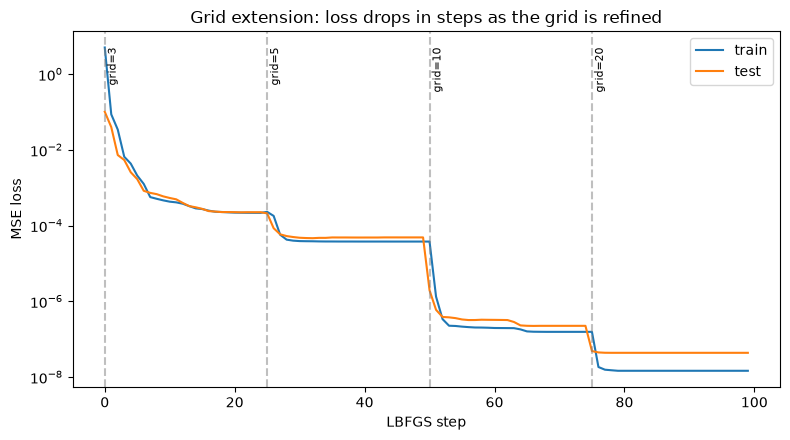

In [5]:
plt.figure(figsize=(8, 4.5))
plt.semilogy(all_train_losses, label="train")
plt.semilogy(all_test_losses, label="test")

ymax = max(max(all_train_losses), max(all_test_losses))
for grid_size, boundary in zip(grid_sizes, stage_boundaries[:-1]):
    plt.axvline(boundary, color="gray", linestyle="--", alpha=0.5)
    plt.text(boundary + 0.3, ymax, f"grid={grid_size}", rotation=90, va="top", fontsize=8)

plt.xlabel("LBFGS step")
plt.ylabel("MSE loss")
plt.legend()
plt.title("Grid extension: loss drops in steps as the grid is refined")
plt.tight_layout()
plt.show()